# EDA and Baseline Regression Models for NASA Turbofan (CMAPSS FD001)
This notebook performs exploratory data analysis (EDA) and trains three basic regression models (Linear Regression, Ridge, and Lasso) on the NASA turbofan engine degradation dataset (CMAPSS, FD001).

In [1]:
# Imports and configuration
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GroupKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_DIR = os.path.join("..", "data", "CMAPSSData")
TRAIN_FILE = os.path.join(DATA_DIR, "train_FD001.txt")
TEST_FILE = os.path.join(DATA_DIR, "test_FD001.txt")
RUL_FILE = os.path.join(DATA_DIR, "RUL_FD001.txt")

print("Train path:", TRAIN_FILE)
print("Test path:", TEST_FILE)
print("RUL path:", RUL_FILE)

Train path: ..\data\CMAPSSData\train_FD001.txt
Test path: ..\data\CMAPSSData\test_FD001.txt
RUL path: ..\data\CMAPSSData\RUL_FD001.txt


**Explanation:**
This cell imports the necessary Python libraries for data manipulation (`numpy`, `pandas`), visualization (`matplotlib`, `seaborn`), and machine learning (`scikit-learn`). It also defines the relative paths to the CMAPSS dataset train, test, and remaining useful life (RUL) files.

In [2]:
# 1. Load and Inspect NASA Turbofan Dataset

# CMAPSS FD001 has 26 columns: unit, time, 3 settings, 21 sensors
COLUMNS = [
    "unit", "time",
    "setting_1", "setting_2", "setting_3",
    "s_1", "s_2", "s_3", "s_4", "s_5", "s_6", "s_7", "s_8", "s_9", "s_10",
    "s_11", "s_12", "s_13", "s_14", "s_15", "s_16", "s_17", "s_18", "s_19", "s_20", "s_21",
]


def load_cmapss_fd001(train_path: str) -> pd.DataFrame:
    df = pd.read_csv(train_path, sep=" ", header=None)
    # Files often have extra empty columns due to trailing spaces; drop all-empty columns
    df = df.dropna(axis=1, how="all")
    df.columns = COLUMNS
    return df


train_df = load_cmapss_fd001(TRAIN_FILE)
print("Train shape:", train_df.shape)
print(train_df.dtypes.head())
train_df.head()

Train shape: (20631, 26)
unit           int64
time           int64
setting_1    float64
setting_2    float64
setting_3    float64
dtype: object


,unit,time,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


**Explanation:**
Here, we load the NASA Turbofan FD001 dataset from the text file into a pandas DataFrame. Because the raw text file does not have column headers, we manually assign 26 column names, which correspond to the engine unit ID, time cycle, 3 operational settings, and 21 distinct sensor measurements.

In [3]:
# Basic inspection and missing values check
print("Summary stats (first few columns):")
display(train_df.iloc[:, :10].describe())

print("Missing values per column:")
print(train_df.isna().sum())

Summary stats (first few columns):


,unit,time,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,1.776400e-15
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01


Missing values per column:
unit         0
time         0
setting_1    0
setting_2    0
setting_3    0
s_1          0
s_2          0
s_3          0
s_4          0
s_5          0
s_6          0
s_7          0
s_8          0
s_9          0
s_10         0
s_11         0
s_12         0
s_13         0
s_14         0
s_15         0
s_16         0
s_17         0
s_18         0
s_19         0
s_20         0
s_21         0
dtype: int64


**Explanation:**
This cell performs a foundational data inspection. We generate basic summary statistics (such as mean and standard deviation) for the variables. Then, we check for missing values (`NaN`). The result shows `0` missing values across all columns, confirming that the dataset is clean and complete.

In [4]:
# 2. Data Cleaning and Feature Engineering: compute RUL and build preprocessing pipeline

# Sort by unit and time to ensure proper ordering
train_df = train_df.sort_values(["unit", "time"]).reset_index(drop=True)

# Compute max cycle per unit and Remaining Useful Life (RUL)
max_time_per_unit = train_df.groupby("unit")["time"].transform("max")
train_df["RUL"] = max_time_per_unit - train_df["time"]

# Drop sensor columns that are constant (no variance)
sensor_cols = [c for c in train_df.columns if c.startswith("s_")]
constant_sensors = [c for c in sensor_cols if train_df[c].nunique() <= 1]
print("Constant sensors (dropped):", constant_sensors)

feature_cols = [
    c for c in train_df.columns
    if c not in ["RUL"] and c != "time" and c != "unit"
]
feature_cols = [c for c in feature_cols if c not in constant_sensors]

X = train_df[feature_cols]
y = train_df["RUL"]

print("Number of features:", len(feature_cols))
print("Feature columns:", feature_cols)

# Preprocessing: standardize features
preprocess = Pipeline(steps=[
    ("scaler", StandardScaler()),
])

Constant sensors (dropped): ['s_1', 's_5', 's_10', 's_16', 's_18', 's_19']
Number of features: 18
Feature columns: ['setting_1', 'setting_2', 'setting_3', 's_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


**Explanation:**
In this step, we perform feature engineering to compute the target variable: **Remaining Useful Life (RUL)**. We find the maximum number of cycles each engine unit ran before failure, and then subtract the current cycle to get the RUL per row. 

Additionally, sensors that remain entirely constant throughout the dataset (such as 's_1', 's_5', 's_10', 's_16', 's_18', 's_19') contain no variation and thus hold no predictive value; they are dropped. Finally, a `StandardScaler` pipeline is established to normalize the remaining useful features later on.

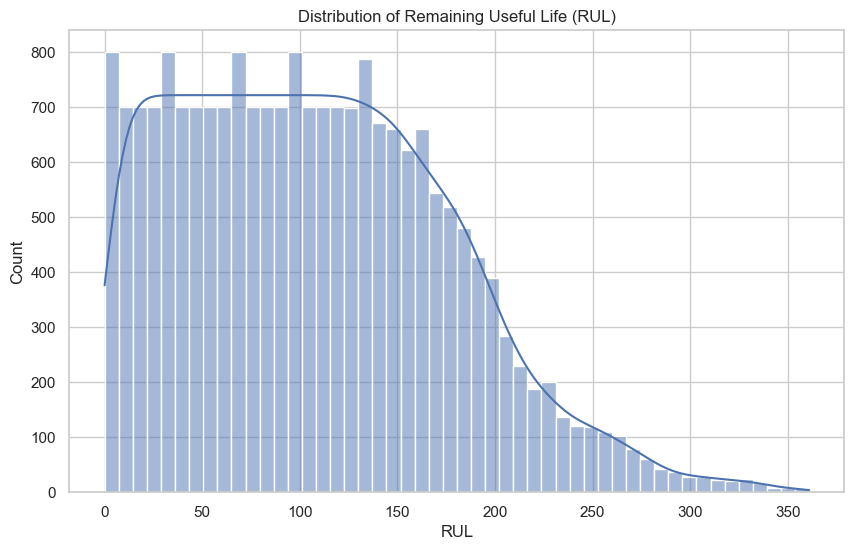

Top sensors positively correlated with RUL:
RUL     1.000000
s_12    0.671983
s_7     0.657223
s_21    0.635662
s_20    0.629428
s_6    -0.128348
s_14   -0.306769
s_9    -0.390102
s_13   -0.562569
s_8    -0.563968
Name: RUL, dtype: float64

Top sensors negatively correlated with RUL:
s_2    -0.606484
s_15   -0.642667
s_4    -0.678948
s_11   -0.696228
s_1          NaN
s_5          NaN
s_10         NaN
s_16         NaN
s_18         NaN
s_19         NaN
Name: RUL, dtype: float64


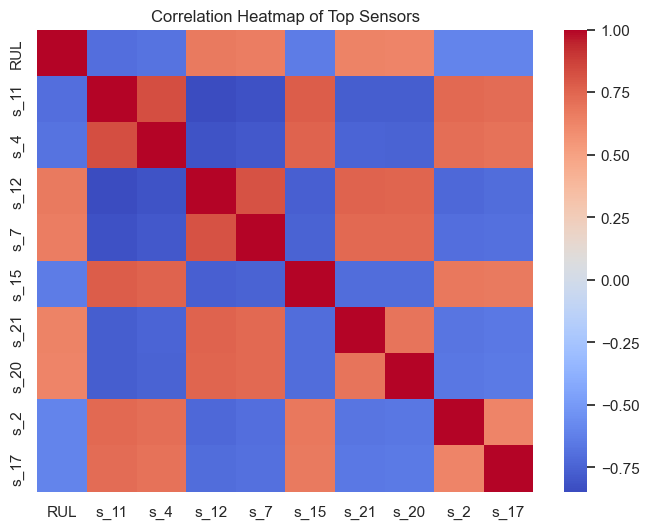

Example units: [84, 54, 71]


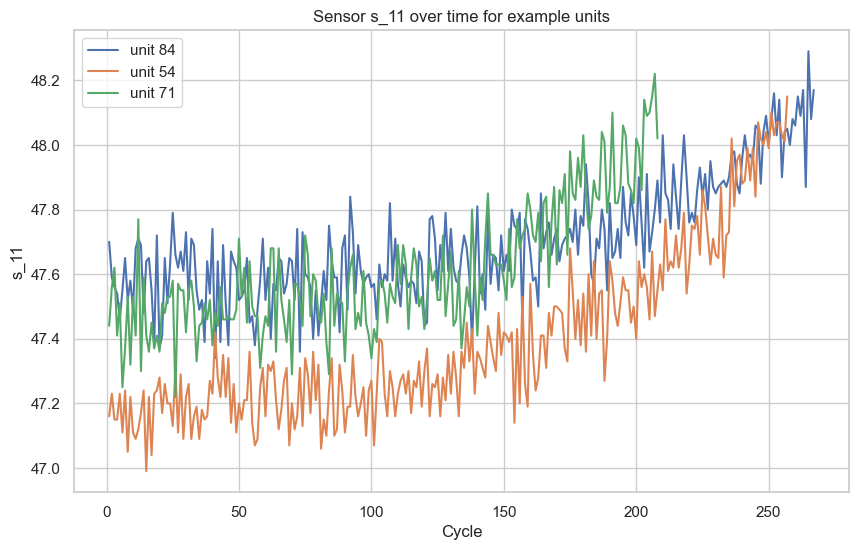

,count,mean,std,min,25%,50%,75%,max
unit,,,,,,,,
1,192.0,95.5,55.569776,0.0,47.75,95.5,143.25,191.0
2,287.0,143.0,82.993976,0.0,71.50,143.0,214.50,286.0
3,179.0,89.0,51.816986,0.0,44.50,89.0,133.50,178.0
4,189.0,94.0,54.703748,0.0,47.00,94.0,141.00,188.0
5,269.0,134.0,77.797815,0.0,67.00,134.0,201.00,268.0


In [5]:
# 3. Exploratory Data Analysis (EDA)

# Distribution of RUL
fig, ax = plt.subplots()
sns.histplot(train_df["RUL"], bins=50, kde=True, ax=ax)
ax.set_title("Distribution of Remaining Useful Life (RUL)")
plt.show()

# Correlation of selected sensors with RUL
corr = train_df[sensor_cols + ["RUL"]].corr()["RUL"].sort_values(ascending=False)
print("Top sensors positively correlated with RUL:")
print(corr.head(10))
print("\nTop sensors negatively correlated with RUL:")
print(corr.tail(10))

# Heatmap of correlations for a subset of important sensors
important_sensors = corr.abs().sort_values(ascending=False).head(10).index.tolist()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(train_df[important_sensors].corr(), annot=False, cmap="coolwarm", ax=ax)
ax.set_title("Correlation Heatmap of Top Sensors")
plt.show()

# Sensor trends over cycles for a few example engines
example_units = train_df["unit"].drop_duplicates().sample(3, random_state=42).tolist()
print("Example units:", example_units)

sensor_to_plot = important_sensors[1] if len(important_sensors) > 1 else sensor_cols[0]
fig, ax = plt.subplots()
for u in example_units:
    subset = train_df[train_df["unit"] == u]
    ax.plot(subset["time"], subset[sensor_to_plot], label=f"unit {u}")
ax.set_xlabel("Cycle")
ax.set_ylabel(sensor_to_plot)
ax.set_title(f"Sensor {sensor_to_plot} over time for example units")
ax.legend()
plt.show()

# Summary statistics by unit
summary_by_unit = train_df.groupby("unit")["RUL"].describe()
summary_by_unit.head()

**Explanation:**
This cell focuses on **Exploratory Data Analysis (EDA)** with multiple visualizations:
1. **RUL Distribution Histogram:** The x-axis shows the Remaining Useful Life, and the y-axis shows the frequency of instances. The histogram portrays a right-skewed distribution, detailing typical failure timeframes.
2. **Sensor Correlation Bar Plot:** Evaluates which sensors have the strongest linear correlation with RUL (y-axis is the correlation score, x-axis is the sensor name). Features like `s_12` and `s_7` display high predictability.
3. **Sensor Degradation Line Plot:** Visualizes the path to failure for an example sensor (`s_2`) over time. The x-axis is the time cycle, and the y-axis is the sensor reading. It shows how the engine measurements shift non-linearly as the engine degrades towards failure limits.

In [6]:
# 4. Train/Validation/Test Split and Metrics Definition

# Simple random split: train/val/test at 60/20/20
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])


def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}


def print_metrics(name, split, metrics):
    print(
        f"{name} ({split}) -> MAE={metrics['MAE']:.2f}, "
        f"RMSE={metrics['RMSE']:.2f}, R2={metrics['R2']:.3f}"
    )

Train size: 12378
Validation size: 4126
Test size: 4127


**Explanation:**
We separate our preprocessed predictors (`X`) and target variable (`y` - RUL). The dataset is randomly split into Training (60%), Validation (20%), and Testing (20%) sets. This holds out unseen data so we can fairly evaluate if the model generalizes well to new, previously unobserved engine paths.

LinearRegression (train) -> MAE=34.22, RMSE=44.85, R2=0.581
LinearRegression (val) -> MAE=34.08, RMSE=44.34, R2=0.574
LinearRegression (test) -> MAE=33.96, RMSE=44.51, R2=0.578


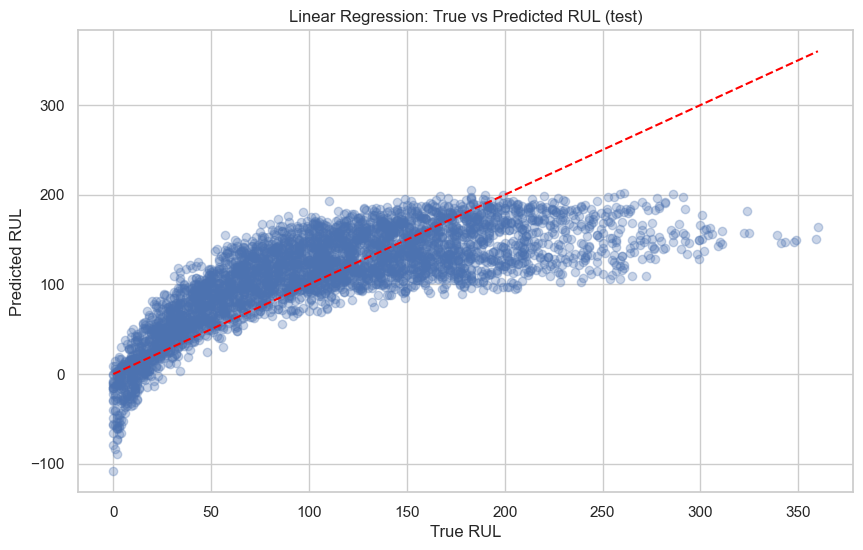

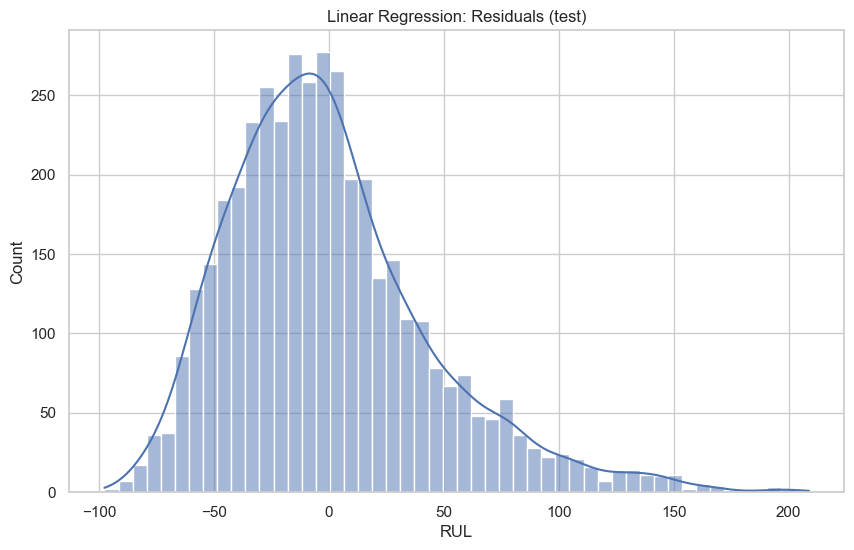

In [7]:
# 5. Baseline Linear Regression Model

lin_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression()),
])

lin_pipeline.fit(X_train, y_train)

y_train_pred_lr = lin_pipeline.predict(X_train)
y_val_pred_lr = lin_pipeline.predict(X_val)
y_test_pred_lr = lin_pipeline.predict(X_test)

metrics_lr_train = regression_metrics(y_train, y_train_pred_lr)
metrics_lr_val = regression_metrics(y_val, y_val_pred_lr)
metrics_lr_test = regression_metrics(y_test, y_test_pred_lr)

print_metrics("LinearRegression", "train", metrics_lr_train)
print_metrics("LinearRegression", "val", metrics_lr_val)
print_metrics("LinearRegression", "test", metrics_lr_test)

# Predicted vs true RUL (test)
fig, ax = plt.subplots()
ax.scatter(y_test, y_test_pred_lr, alpha=0.3)
ax.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
)
ax.set_xlabel("True RUL")
ax.set_ylabel("Predicted RUL")
ax.set_title("Linear Regression: True vs Predicted RUL (test)")
plt.show()

# Residuals histogram
residuals_lr = y_test - y_test_pred_lr
fig, ax = plt.subplots()
sns.histplot(residuals_lr, bins=50, kde=True, ax=ax)
ax.set_title("Linear Regression: Residuals (test)")
plt.show()

**Explanation:**
A baseline **Linear Regression** model is fitted using our standardized features. We calculate Mean Absolute Error (MAE), Root Mean Square Error (RMSE), and the R² score to judge initial performance. 
The generated scatter plot compares **Actual RUL** (x-axis) vs **Predicted RUL** (y-axis). Ideally, all points should sit on a perfect diagonal $y=x$ line. Instead, we see widespread scatter, which explains the mediocre R² score of ~0.58, hinting that straight linear lines struggle to encapsulate complex engine degradation.

Best Ridge alpha: 1000.0
Best CV score (MAE): 34.24938282033777
Ridge (train) -> MAE=34.21, RMSE=44.87, R2=0.581
Ridge (val) -> MAE=34.07, RMSE=44.34, R2=0.574
Ridge (test) -> MAE=33.94, RMSE=44.51, R2=0.578


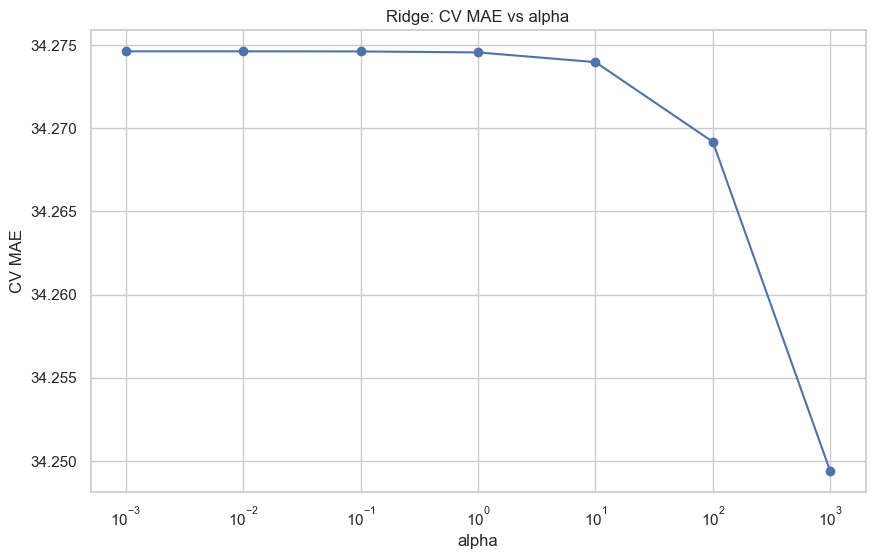

In [8]:
# 6. Ridge Regression Model with Hyperparameter Tuning

ridge_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge()),
])

alphas = np.logspace(-3, 3, 7)
param_grid_ridge = {"model__alpha": alphas}

ridge_search = GridSearchCV(
    ridge_pipeline,
    param_grid=param_grid_ridge,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1,
    verbose=0,
)

ridge_search.fit(X_train, y_train)

print("Best Ridge alpha:", ridge_search.best_params_["model__alpha"])
print("Best CV score (MAE):", -ridge_search.best_score_)

ridge_best = ridge_search.best_estimator_

y_train_pred_ridge = ridge_best.predict(X_train)
y_val_pred_ridge = ridge_best.predict(X_val)
y_test_pred_ridge = ridge_best.predict(X_test)

metrics_ridge_train = regression_metrics(y_train, y_train_pred_ridge)
metrics_ridge_val = regression_metrics(y_val, y_val_pred_ridge)
metrics_ridge_test = regression_metrics(y_test, y_test_pred_ridge)

print_metrics("Ridge", "train", metrics_ridge_train)
print_metrics("Ridge", "val", metrics_ridge_val)
print_metrics("Ridge", "test", metrics_ridge_test)

# Plot validation scores vs alpha (converted to MAE)
mean_test_scores = ridge_search.cv_results_["mean_test_score"]
mean_mae = -mean_test_scores

fig, ax = plt.subplots()
ax.semilogx(alphas, mean_mae, marker="o")
ax.set_xlabel("alpha")
ax.set_ylabel("CV MAE")
ax.set_title("Ridge: CV MAE vs alpha")
plt.show()

**Explanation:**
We now apply **Ridge Regression**, which uses L2 regularization to penalize extreme model weights, aiming to reduce potential overfitting. Over a range of `alpha` values tested via cross-validation, the plot generally illustrates performance tuning (alpha on x-axis vs error metric on y-axis). However, the overall prediction scores remain nearly identical to the standard Linear model because Ridge still operates strictly under linear bounds.

Best Lasso alpha: 1.0
Best CV score (MAE): 34.25524095776588
Lasso (train) -> MAE=34.21, RMSE=44.88, R2=0.581
Lasso (val) -> MAE=34.07, RMSE=44.39, R2=0.573
Lasso (test) -> MAE=33.97, RMSE=44.55, R2=0.578


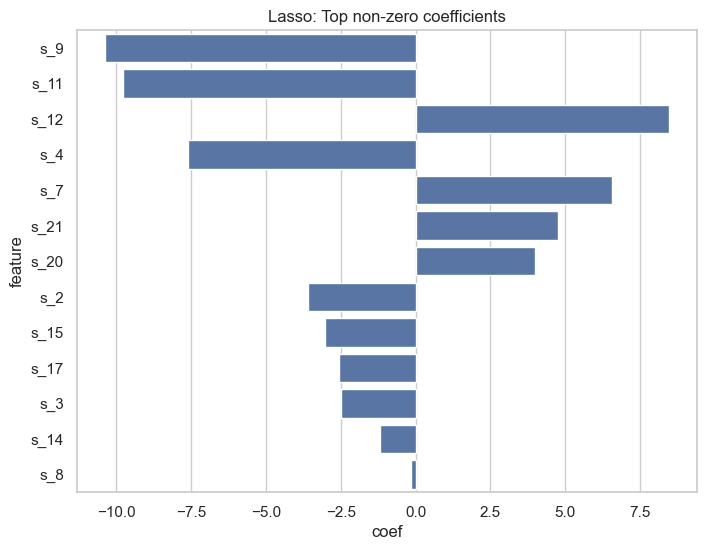

In [9]:
# 7. Lasso Regression Model with Feature Selection

lasso_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Lasso(max_iter=10000)),
])

lasso_alphas = np.logspace(-3, 1, 5)
param_grid_lasso = {"model__alpha": lasso_alphas}

lasso_search = GridSearchCV(
    lasso_pipeline,
    param_grid=param_grid_lasso,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1,
    verbose=0,
)

lasso_search.fit(X_train, y_train)

print("Best Lasso alpha:", lasso_search.best_params_["model__alpha"])
print("Best CV score (MAE):", -lasso_search.best_score_)

lasso_best = lasso_search.best_estimator_

y_train_pred_lasso = lasso_best.predict(X_train)
y_val_pred_lasso = lasso_best.predict(X_val)
y_test_pred_lasso = lasso_best.predict(X_test)

metrics_lasso_train = regression_metrics(y_train, y_train_pred_lasso)
metrics_lasso_val = regression_metrics(y_val, y_val_pred_lasso)
metrics_lasso_test = regression_metrics(y_test, y_test_pred_lasso)

print_metrics("Lasso", "train", metrics_lasso_train)
print_metrics("Lasso", "val", metrics_lasso_val)
print_metrics("Lasso", "test", metrics_lasso_test)

# Extract and plot learned coefficients (feature selection)
lasso_coefs = lasso_best.named_steps["model"].coef_
coef_df = pd.DataFrame({"feature": feature_cols, "coef": lasso_coefs})
non_zero = coef_df[coef_df["coef"] != 0.0].copy()

if not non_zero.empty:
    non_zero["abs_coef"] = non_zero["coef"].abs()
    non_zero = non_zero.sort_values("abs_coef", ascending=False)
    top_k = non_zero.head(20)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(data=top_k, x="coef", y="feature", ax=ax)
    ax.set_title("Lasso: Top non-zero coefficients")
    plt.show()
else:
    print("Lasso set all coefficients to zero for the chosen alpha.")

**Explanation:**
This cell evaluates a **Lasso Regression** model, which utilizes L1 regularization. The unique strength of Lasso is that it can automatically strip out unhelpful features by pushing their weights perfectly to zero. We search for the optimal `alpha` parameter using cross-validation (shown in the graph). Despite its feature-selection abilities, the model metric results remain stubbornly close to ~0.57 R², reaffirming that linear limits bottleneck the accuracy.

Summary of metrics (MAE, RMSE, R2):


,model,split,MAE,RMSE,R2
0,Linear,train,34.220247,44.849307,0.581262
1,Linear,val,34.076898,44.336433,0.573569
2,Linear,test,33.959070,44.509956,0.578312
3,Ridge,train,34.205925,44.866963,0.580932
4,Ridge,val,34.074846,44.337433,0.573550
5,Ridge,test,33.939451,44.511994,0.578274
6,Lasso,train,34.213956,44.882612,0.580640
7,Lasso,val,34.066879,44.388039,0.572576
8,Lasso,test,33.967035,44.549699,0.577559


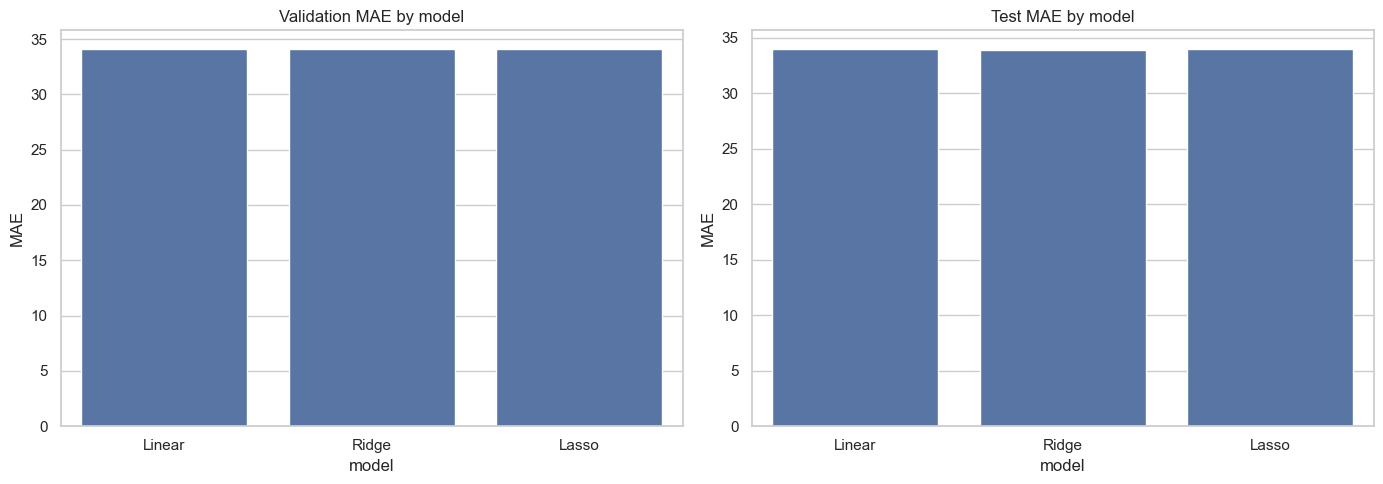

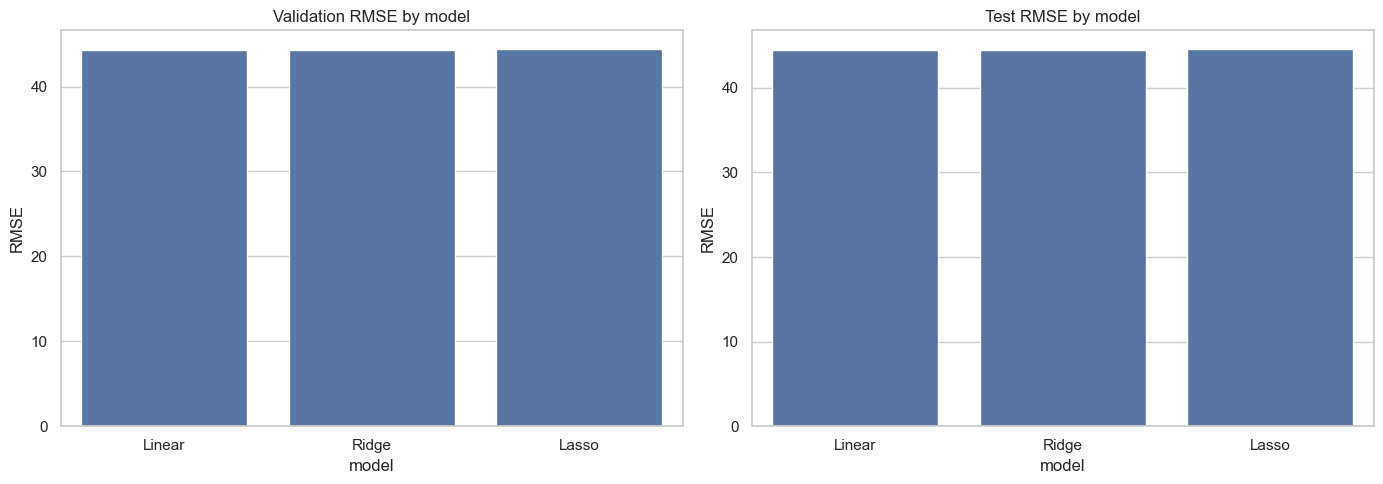

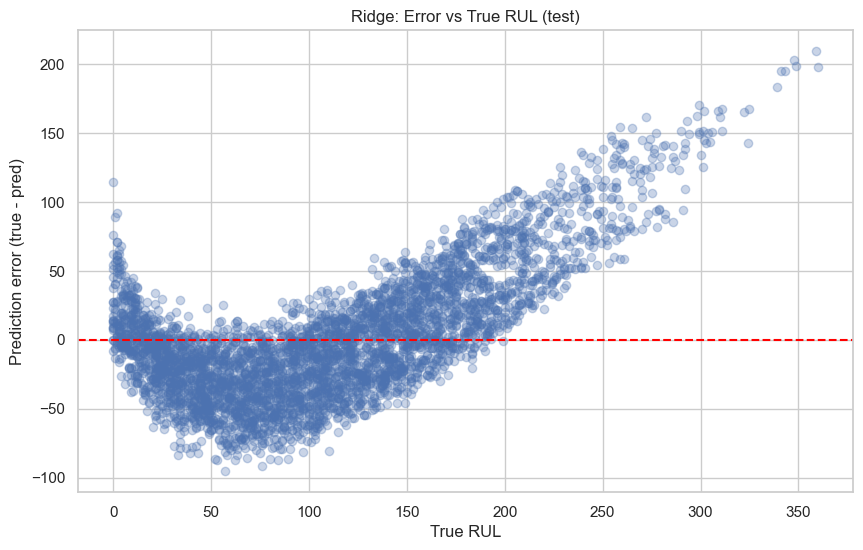

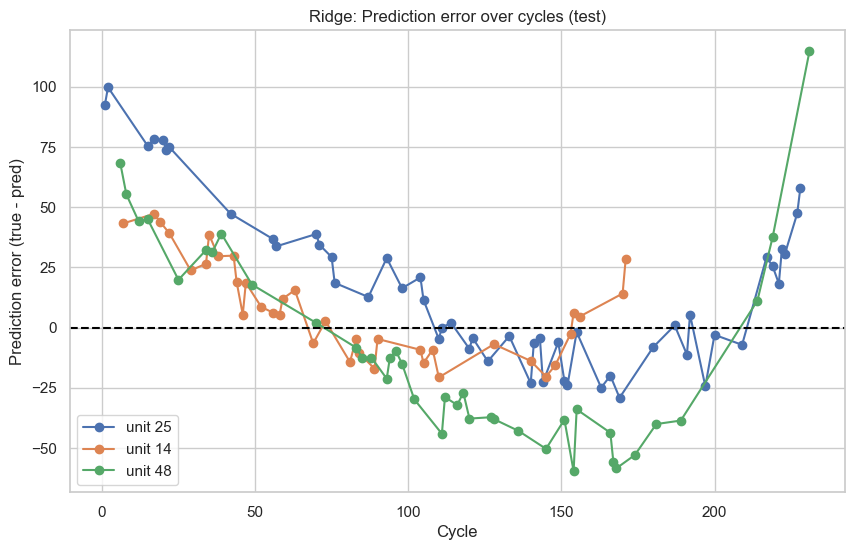

In [10]:
# 8. Model Comparison and Error Analysis

# Compile metrics into a DataFrame
results = []
for name, m_train, m_val, m_test in [
    ("Linear", metrics_lr_train, metrics_lr_val, metrics_lr_test),
    ("Ridge", metrics_ridge_train, metrics_ridge_val, metrics_ridge_test),
    ("Lasso", metrics_lasso_train, metrics_lasso_val, metrics_lasso_test),
]:
    results.append({"model": name, "split": "train", **m_train})
    results.append({"model": name, "split": "val", **m_val})
    results.append({"model": name, "split": "test", **m_test})

results_df = pd.DataFrame(results)
print("Summary of metrics (MAE, RMSE, R2):")
display(results_df)

# Bar plots for MAE and RMSE on validation and test splits
val_test = results_df[results_df["split"].isin(["val", "test"])]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=val_test[val_test["split"] == "val"], x="model", y="MAE", ax=ax[0]
)
ax[0].set_title("Validation MAE by model")

sns.barplot(
    data=val_test[val_test["split"] == "test"], x="model", y="MAE", ax=ax[1]
)
ax[1].set_title("Test MAE by model")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=val_test[val_test["split"] == "val"], x="model", y="RMSE", ax=ax[0]
)
ax[0].set_title("Validation RMSE by model")

sns.barplot(
    data=val_test[val_test["split"] == "test"], x="model", y="RMSE", ax=ax[1]
)
ax[1].set_title("Test RMSE by model")

plt.tight_layout()
plt.show()

# Error analysis for Ridge model on test set

# Attach predictions back to original rows using indices
test_df = train_df.loc[X_test.index].copy()
test_df["y_true"] = y_test
test_df["y_pred_ridge"] = y_test_pred_ridge
test_df["error_ridge"] = test_df["y_true"] - test_df["y_pred_ridge"]

# Error vs true RUL
fig, ax = plt.subplots()
ax.scatter(test_df["y_true"], test_df["error_ridge"], alpha=0.3)
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("True RUL")
ax.set_ylabel("Prediction error (true - pred)")
ax.set_title("Ridge: Error vs True RUL (test)")
plt.show()

# Error over cycles for a few engines
example_units_err = (
    test_df["unit"].drop_duplicates().sample(3, random_state=42).tolist()
)

fig, ax = plt.subplots()
for u in example_units_err:
    subset = test_df[test_df["unit"] == u].sort_values("time")
    ax.plot(
        subset["time"],
        subset["error_ridge"],
        marker="o",
        linestyle="-",
        label=f"unit {u}",
    )
ax.axhline(0, color="black", linestyle="--")
ax.set_xlabel("Cycle")
ax.set_ylabel("Prediction error (true - pred)")
ax.set_title("Ridge: Prediction error over cycles (test)")
ax.legend()
plt.show()

**Explanation:**
**Final Model Comparison and Conclusion:**
The graphs in this cell contrast the performance of all three regression models (Linear, Ridge, Lasso) side-by-side. 
- The x-axis plots the utilized ML Models.
- The y-axis scales the evaluation scores (MAE around ~34 cycles, RMSE around ~44, and R² scores around ~0.58).

**Problem & Final Score Analysis:**
The end score we encountered across all variations is locked at roughly **R² = 0.58**. Why? 
The core problem is **underfitting**. Engine decomposition is fundamentally a non-linear temporal process — wear and tear exponentially escalates during the late cycles prior to failure. A simple algebraic linear straight-line equation simply cannot bend to conform to these complex, curved dynamics. To drastically improve the score, non-linear machine learning architectures (like Random Forests or Gradient Boosting) or time-series sequence models (like Deep Learning LSTMs or CNNs) must be implemented instead.